#  Introduction

-----------------------------------------------------

This notebook include step by step thought process. It's to help me with my own 
1. Load and explore data
2. Data visualization
3. Preprocess and clean data
4. Choose the right model
5. Tune and Optimize
6. Deploy the model and submit the result


-----------------------------------------------------

# Load Basic Library

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import train_test_split

In [2]:
# Import gradient boosting libraries
import lightgbm as lgb
import xgboost as xgb
import catboost as catb

In [3]:
# Setup plotting
import matplotlib.pyplot as plt

plt.style.use('seaborn-whitegrid')
# Set Matplotlib defaults
plt.rc('figure', autolayout=True)
plt.rc('axes', labelweight='bold', labelsize='large',
       titleweight='bold', titlesize=18, titlepad=10)

/tmp/ipykernel_13/3251733192.py:4: MatplotlibDeprecationWarning: The seaborn styles shipped by Matplotlib are deprecated since 3.6, as they no longer correspond to the styles shipped by seaborn. However, they will remain available as 'seaborn-v0_8-<style>'. Alternatively, directly use the seaborn API instead.
  plt.style.use('seaborn-whitegrid')


-----------------------------------------------------

Set random seed to have reproducibile result

-----------------------------------------------------

In [4]:
# For reproducibility
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# Load & explore data

In [5]:
train = pd.read_csv('/kaggle/input/playground-series-s5e10/train.csv')
test = pd.read_csv('/kaggle/input/playground-series-s5e10/test.csv')
sample_submission = pd.read_csv('/kaggle/input/playground-series-s5e10/sample_submission.csv')  

In [6]:
print("______________Train data______________")
print(train.head())
print("______________Test data______________")
print(test.head())
print(sample_submission.head())

______________Train data______________
   id road_type  num_lanes  curvature  speed_limit  lighting weather  \
0   0     urban          2       0.06           35  daylight   rainy   
1   1     urban          4       0.99           35  daylight   clear   
2   2     rural          4       0.63           70       dim   clear   
3   3   highway          4       0.07           35       dim   rainy   
4   4     rural          1       0.58           60  daylight   foggy   

   road_signs_present  public_road time_of_day  holiday  school_season  \
0               False         True   afternoon    False           True   
1                True        False     evening     True           True   
2               False         True     morning     True          False   
3                True         True     morning    False          False   
4               False        False     evening     True          False   

   num_reported_accidents  accident_risk  
0                       1           0.13

-----------------------------------------------------

Because there are many data that can not be recognized by model.(category data and boolean)\
We know that preprocess need to include encoding part.

-----------------------------------------------------

In [7]:
# Display information about the datasets
print("Train data shape")
print(train.shape)
print("Test data shape")
print(test.shape)
print("sample_submission data shape")
print(sample_submission.shape)

Train data shape
(517754, 14)
Test data shape
(172585, 13)
sample_submission data shape
(172585, 2)


In [8]:
# basic statistics
print(train['accident_risk'].describe())

count    517754.000000
mean          0.352377
std           0.166417
min           0.000000
25%           0.230000
50%           0.340000
75%           0.460000
max           1.000000
Name: accident_risk, dtype: float64


-----------------------------------------------------

It's not very clear from the summary above.\
So I decide to make it understandable by visualizing it.\
Check miss data is also very important.\
This can also make sure what we need to do when it comes to preprocess data

-----------------------------------------------------

In [9]:
train.isnull().sum()

id                        0
road_type                 0
num_lanes                 0
curvature                 0
speed_limit               0
lighting                  0
weather                   0
road_signs_present        0
public_road               0
time_of_day               0
holiday                   0
school_season             0
num_reported_accidents    0
accident_risk             0
dtype: int64

# Data Visualization

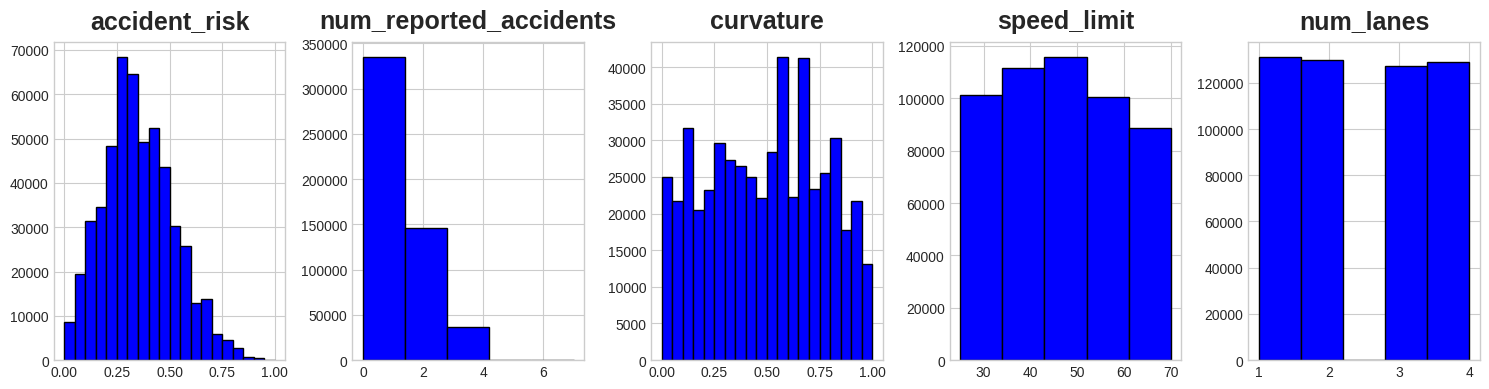

In [10]:
# Create subplots
fig, axs = plt.subplots(1, 5, figsize=(15, 4))  # 1 row, 5 columns

axs[0].hist(train['accident_risk'], bins=20, color='blue', edgecolor='black')
axs[0].set_title('accident_risk')

axs[1].hist(train['num_reported_accidents'], bins=5, color='blue', edgecolor='black')
axs[1].set_title('num_reported_accidents')

axs[2].hist(train['curvature'], bins=20, color='blue', edgecolor='black')
axs[2].set_title('curvature')

axs[3].hist(train['speed_limit'], bins=5, color='blue', edgecolor='black')
axs[3].set_title('speed_limit')

axs[4].hist(train['num_lanes'], bins=5, color='blue', edgecolor='black')
axs[4].set_title('num_lanes')
#accident_risk, num_reported_accidents
plt.tight_layout()
plt.show()


# Encode the data

-----------------------------------------------------

Because some data is not number and it can not be recognize by model.\
We have to encode it so that machine learning model can process it

-----------------------------------------------------

In [11]:
#road_type,lighting ,weather,time_of_day
#following feature need to be encode with "Label Encodeing"

from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()
road_type_encoded = encoder.fit_transform(train["road_type"])
lighting_encoded = encoder.fit_transform(train["lighting"])
weather_encoded = encoder.fit_transform(train["weather"])
time_of_day_encoded = encoder.fit_transform(train["time_of_day"])

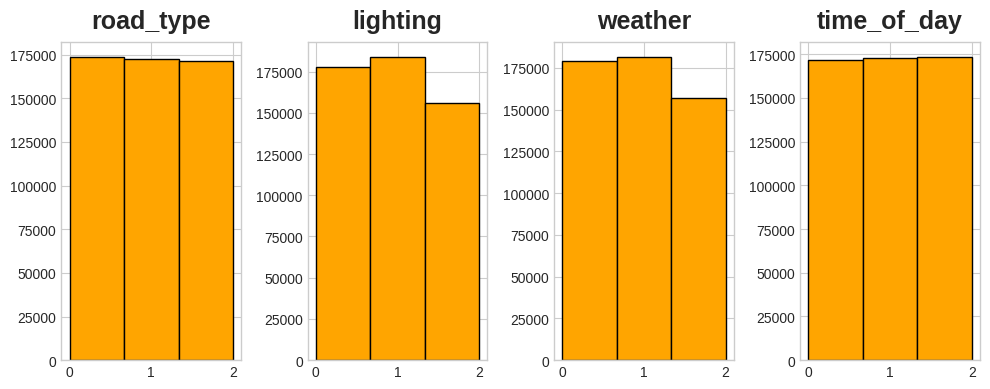

In [12]:
# Create subplots
fig, axs = plt.subplots(1, 4, figsize=(10, 4))  # 1 row, 4 columns

axs[0].hist(road_type_encoded, bins=3, color='orange', edgecolor='black')
axs[0].set_title('road_type')

axs[1].hist(lighting_encoded, bins=3, color='orange', edgecolor='black')
axs[1].set_title('lighting')

axs[2].hist(weather_encoded, bins=3, color='orange', edgecolor='black')
axs[2].set_title('weather')

axs[3].hist(time_of_day_encoded, bins=3, color='orange', edgecolor='black')
axs[3].set_title('time_of_day')

#accident_risk, num_reported_accidents
plt.tight_layout()
plt.show()


In [13]:
#road_signs_present,public_road,holiday,school_season
#following feature need to be encode with "One-Hot Encodeing"
# True → 1, False → 0
road_signs_present_encoded = [int(x) for x in train["road_signs_present"]]  
public_road_encoded = [int(x) for x in train["public_road"]]  
holiday_encoded = [int(x) for x in train["holiday"]]  
school_season_encoded = [int(x) for x in train["school_season"]]  

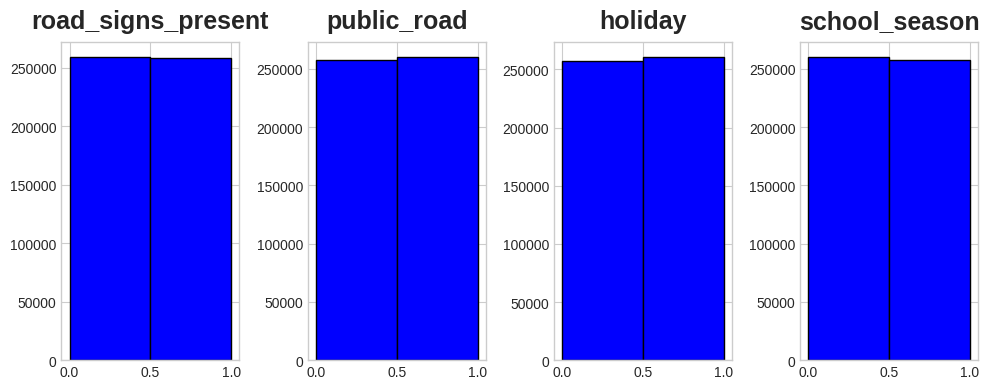

In [14]:
# Create subplots
fig, axs = plt.subplots(1, 4, figsize=(10, 4))  # 1 row, 4 columns

axs[0].hist(road_signs_present_encoded, bins=2, color='blue', edgecolor='black')
axs[0].set_title('road_signs_present')

axs[1].hist(public_road_encoded, bins=2, color='blue', edgecolor='black')
axs[1].set_title('public_road')

axs[2].hist(holiday_encoded, bins=2, color='blue', edgecolor='black')
axs[2].set_title('holiday')

axs[3].hist(school_season_encoded, bins=2, color='blue', edgecolor='black')
axs[3].set_title('school_season')

#accident_risk, num_reported_accidents
plt.tight_layout()
plt.show()


-----------------------------------------------------

We can see that there is no outlier by the image above.\
But we need to encode some data in preprocess step

-----------------------------------------------------

# Set our data preprocess function

In [15]:
from sklearn.preprocessing import PolynomialFeatures
def preprocess_dataframe(df: pd.DataFrame, drop_cols: list = None) -> pd.DataFrame:
    df = df.copy()

    # Handle missing values
    # Althought there are no missing data
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())
    
    # Step 0: Drop specified columns 
    
    if drop_cols:
        df = df.drop(columns=drop_cols, errors='ignore')  # 'ignore' avoids errors if column not found

    # Step 1: Encode boolean columns
    bool_cols = df.select_dtypes(include='bool').columns
    df[bool_cols] = df[bool_cols].astype(int)

    # Step 2: Label encode categorical columns
    label_encoders = {}
    for col in df.select_dtypes(include=['object', 'category']).columns:
        le = LabelEncoder()
        df[col] = le.fit_transform(df[col])
        label_encoders[col] = le
    # Step 3: Polynomial features
    poly = PolynomialFeatures(degree=2, interaction_only=True, include_bias=False)
    poly_features = poly.fit_transform(df[['num_lanes', 'curvature']])
    poly_cols = [f'poly_{i}' for i in range(poly_features.shape[1])]
    df[poly_cols] = poly_features
    
    return df

In [16]:
preprocess_train = preprocess_dataframe(train,drop_cols=['accident_risk','id'])

In [17]:
preprocess_train

,road_type,num_lanes,curvature,speed_limit,lighting,weather,road_signs_present,public_road,time_of_day,holiday,school_season,num_reported_accidents,poly_0,poly_1,poly_2
0,2,2,0.06,35,0,2,0,1,0,0,1,1,2.0,0.06,0.12
1,2,4,0.99,35,0,0,1,0,1,1,1,0,4.0,0.99,3.96
2,1,4,0.63,70,1,0,0,1,2,1,0,2,4.0,0.63,2.52
3,0,4,0.07,35,1,2,1,1,2,0,0,1,4.0,0.07,0.28
4,1,1,0.58,60,0,1,0,0,1,1,0,1,1.0,0.58,0.58
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
517749,0,4,0.10,70,0,1,1,1,0,0,0,2,4.0,0.10,0.40
517750,1,4,0.47,35,0,2,1,1,2,0,0,1,4.0,0.47,1.88
517751,2,4,0.62,25,0,1,0,0,0,0,1,0,4.0,0.62,2.48
517752,0,3,0.63,25,2,0,1,0,0,1,1,3,3.0,0.63,1.89


# Set up a pipline to experience for better model

-----------------------------------------------------

I need to add test data score into the return data to find out if it is overfitting

Now we need to chose model for the question. \
Here are some tips when it comes to these three model. 

*Use LightGBM when:*
- You have large datasets or high-dimensional features.
- You want fast training and low memory usage.

*Use XGBoost when:*
- You need a well-tested, flexible model with strong performance.
- You’re doing hyperparameter tuning or competing in ML challenges.

*Use CatBoost when:*
- Your data has many categorical features.
- You want strong default performance with minimal preprocessing.


-----------------------------------------------------

In [18]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.model_selection import cross_val_score
from xgboost import XGBRegressor
def get_score(n_estimators):
    """Return the average MAE over 5 CV folds of XGBRegressor model.
    
    Keyword argument:
    n_estimators -- the number of trees in the forest
    """
    my_pipeline = Pipeline(steps=[
        ('preprocessor', SimpleImputer(strategy='median')),# more robust to outliers
        ('model', XGBRegressor(n_estimators=n_estimators, learning_rate=0.05) )
    ])
    scores = -1 * cross_val_score(my_pipeline, X_train_final, y_train_fianl,
                              cv=5,
                              scoring='neg_mean_absolute_error')
    cv_mae = scores.mean()
    
    # Fit on full training set
    my_pipeline.fit(X_train_final, y_train_fianl)
    
    # Validation score
    valid_preds = my_pipeline.predict(X_valid)
    valid_mae = mean_absolute_error(y_valid, valid_preds)
    
    #print(f"CV MAE: {cv_mae:.4f}")
    #print(f"Validation MAE: {valid_mae:.4f}")

    return cv_mae, valid_mae


# Now preprocess data and fit XGBRegressor model

In [19]:
train_data = preprocess_dataframe(train,drop_cols=['id'])
test_data_id = test['id']
test_data = preprocess_dataframe(test,drop_cols=['id'])

In [20]:
train_x = train_data.drop(['accident_risk'] , axis=1)
train_y = train_data['accident_risk']

In [21]:
X_train_final, X_valid, y_train_fianl, y_valid = train_test_split(train_x, train_y, train_size=0.8, test_size=0.2,random_state=0)

In [22]:
#10/22/2025 update for checking if the parameter is overfitting
cv_results = {}
valid_results = {}

for i in range(1, 30):
    n = 10 * i
    cv_mae, valid_mae = get_score(n)
    cv_results[n] = cv_mae
    valid_results[n] = valid_mae


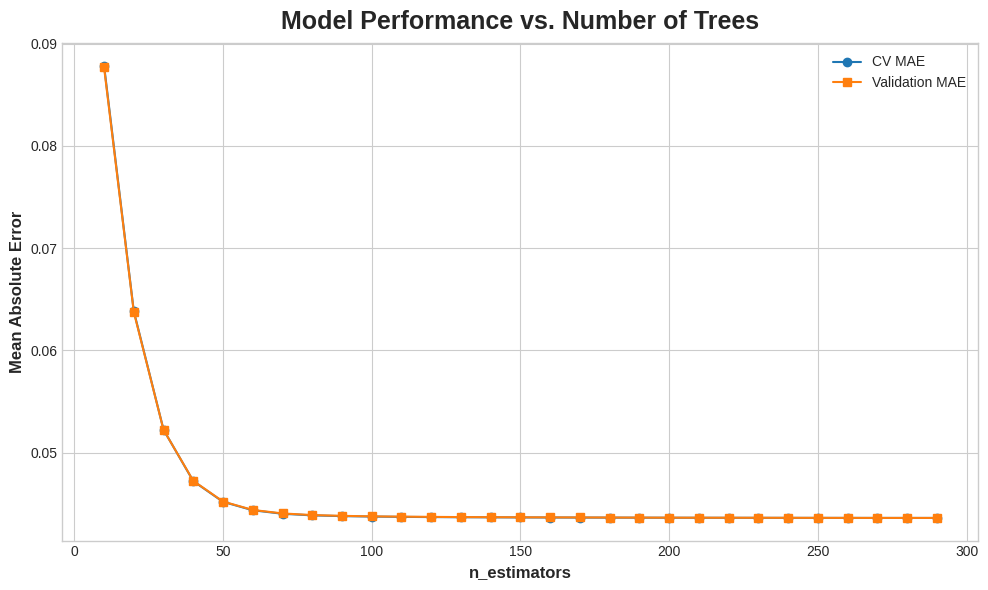

In [23]:
import matplotlib.pyplot as plt
%matplotlib inline

plt.figure(figsize=(10, 6))
plt.plot(list(cv_results.keys()), list(cv_results.values()), label='CV MAE', marker='o')
plt.plot(list(valid_results.keys()), list(valid_results.values()), label='Validation MAE', marker='s')
plt.xlabel('n_estimators')
plt.ylabel('Mean Absolute Error')
plt.title('Model Performance vs. Number of Trees')
plt.legend()
plt.grid(True)
plt.show()


From the graph above we can tell that as "n_estimators" parameter goes up result is getting better.
But there is one thing we need to take into consider.
Overfitting is a reason it could cause.
So we need to check if there is overfitting problem.

# Predict test data to generate final prediction

In [24]:
# Define the model
my_model_1 = XGBRegressor(n_estimators=100, learning_rate=0.05) 

# Fit the model
my_model_1.fit(X_train_final, y_train_fianl)

# Get predictions
predictions_1 = my_model_1.predict(X_valid)

# Calculate MAE
mae_1 =  mean_absolute_error(predictions_1, y_valid)

# Uncomment to print MAE
print("Mean Absolute Error:" , mae_1)

Mean Absolute Error: 0.043783416263957355


In [25]:
# Define the model
my_model_2 = XGBRegressor(n_estimators=200, learning_rate=0.05) 

# Fit the model
my_model_2.fit(X_train_final, y_train_fianl)

# Get predictions
predictions_2 = my_model_2.predict(X_valid)

# Calculate MAE
mae_2 =  mean_absolute_error(predictions_2, y_valid)

# Uncomment to print MAE
print("Mean Absolute Error:" , mae_2)

Mean Absolute Error: 0.04365485480053972


In [26]:
# Define the model
my_model_3 = XGBRegressor(n_estimators=300, learning_rate=0.05) 

# Fit the model
my_model_3.fit(X_train_final, y_train_fianl)

# Get predictions
predictions_3 = my_model_3.predict(X_valid)

# Calculate MAE
mae_3 =  mean_absolute_error(predictions_3, y_valid)

# Uncomment to print MAE
print("Mean Absolute Error:" , mae_3)

Mean Absolute Error: 0.043628712064681184


In [27]:
final_preds = np.round(my_model_3.predict(test_data),3)

In [28]:
print(final_preds)

[0.293 0.124 0.187 ... 0.253 0.127 0.487]


# Preparing the Submission

In [29]:
submission = pd.DataFrame({'id': test_data_id, 'accident_risk': final_preds})
submission.to_csv('submission.csv', index=False)
display(submission.head())

,id,accident_risk
0,517754,0.293
1,517755,0.124
2,517756,0.187
3,517757,0.321
4,517758,0.405
